Reproduce the the standard pincell, but let's see how $k_{\infty}$ varies with enrichment. Recall, k is the multiplication factor; the ratio between neutron population following nth generation to neutron population during nth generation.  If k > 1, the chain reaction is supercritical; neutron population will grow exponentially, if k = 1, the chain reaction is critical and the neutron population will remain constant, if k < 1, the chain reaction is subcritical and the neutron population will exponentially decay.  In an infinite medium (like our pincell), neutrons cannot leak out of the system and multiplication factor becomes the infinite multiplication factor $k = k_{\infty}$. This is approximated by the four-factor formula: https://en.wikipedia.org/wiki/Four_factor_formula

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import openmc

# Running openmc as is will usually crash when you call the plot() method.  This is because OPENMC_CROSS_SECTIONS is not set in the notebook environment
import os       
os.environ['OPENMC_CROSS_SECTIONS'] = os.path.expanduser(
    '~/openmc-data/endfb-viii.0-hdf5/cross_sections.xml'
)

# We also need to define the path to the openmc executable
os.environ['PATH'] = os.path.expanduser('~/openmc-source/build/bin') + ':' + os.environ['PATH'] 

In [2]:
# Additional imports
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

In [3]:
# directory_ = '../../../openmc_data/pincell_varying_enrichment_example'
directory_ =  directory_ = os.path.abspath('../../../openmc_data/pincell_varying_enrichment_example')

### Pin cell geometry

Now we can create a pin-cell.  We need three surfaces to define the fuel and clad:

1. The outer surface of the fuel -- a cylinder parallel to the z axis

2. The inner surface of the clad -- same as the above

3. The outer surface of the clad -- same as above

In [4]:
# The actual geometry is constant so we only need to define it once
fuel_outer_radius = openmc.ZCylinder(r=0.39)
clad_inner_radius = openmc.ZCylinder(r=0.40)
clad_outer_radius = openmc.ZCylinder(r=0.46)

In [5]:
fuel_region = -fuel_outer_radius 
gap_region = +fuel_outer_radius & -clad_inner_radius 
clad_region = +clad_inner_radius & -clad_outer_radius 

In [6]:
# now define the fuel cell, gap, and clad region 
fuel = openmc.Cell(name='fuel')
fuel.region = fuel_region 

gap = openmc.Cell(name='air gap')
gap.region = gap_region 

clad = openmc.Cell(name='clad')
clad.region = clad_region

In [7]:
# Define the coolant region outside of the fuel pin:
pitch = 1.26 
left = openmc.XPlane(-pitch/2, boundary_type='reflective')
right = openmc.XPlane(pitch/2, boundary_type='reflective')
bottom = openmc.YPlane(-pitch/2, boundary_type='reflective')
top = openmc.YPlane(pitch/2, boundary_type='reflective')

In [8]:
# Use water as the coolant. The water region is going to be everything outside the clad outer radius and within the box formed as the intersection of the four half-spaces above
water_region = +left & -right & + bottom & -top & +clad_outer_radius 

moderator = openmc.Cell(name='moderator')
moderator.region = water_region

In [9]:
# Now define materials that we will be constant, that's the moderator and the cladding 
water = openmc.Material(name='h20')
water.add_nuclide('H1', 2.0)
water.add_nuclide('O16', 1.0)
water.set_density('g/cm3', 1.0)

water.add_s_alpha_beta('c_H_in_H2O')

In [10]:
zirconium = openmc.Material(name='zirconium')
zirconium.add_element('Zr', 1.0)
zirconium.set_density('g/cm3', 6.6)

In [11]:
# Fill in the constant material regions 
clad.fill = zirconium 
moderator.fill = water

In [12]:
# Now, define the degrees of enrichment we want to test. Consider 2% enrichment, through 10%. Step through at 0.5% enrichment by wt
enrichment_values = list(np.arange(2.0, 10.5, 0.5))
# enrichment_values = list(np.arange(2.0, 3.5, 0.5))
enrichment_values = [x / 100 for x in enrichment_values]

In [13]:
# We'll want a point source. This will be the same throughout enrichment values 
point = openmc.stats.Point((0, 0, 0))
source = openmc.IndependentSource(space=point) 

settings = openmc.Settings()
settings.source = source 
settings.batches = 100 
settings.inactive = 10
settings.particles = 1000
settings.export_to_xml(os.path.join(directory_, 'settings.xml'))

In [14]:
keff_dict = {}
for i, enrich_ in enumerate(enrichment_values):
    uo2 = openmc.Material(name="uo2")
    uo2.add_nuclide('U235', enrich_)
    uo2.add_nuclide('U238', 1 - enrich_)
    uo2.add_nuclide('O16', 2.0)
    uo2.set_density('g/cm3', 10.0)

    fuel.fill = uo2 

    materials = openmc.Materials() 
    materials.append(uo2)
    materials += [zirconium, water]
    materials.export_to_xml(os.path.join(directory_, 'materials.xml'))

    root_universe = openmc.Universe(cells=(fuel, gap, clad, moderator)) 
    geometry = openmc.Geometry(root_universe) 
    geometry.export_to_xml(os.path.join(directory_, 'geometry.xml'))

    # Run simulations
    openmc.run(cwd=directory_, output=False)

    # Get the data we need
    sp_ = openmc.StatePoint(os.path.join(directory_, 'statepoint.100.h5'))
    k_eff = sp_.keff.nominal_value
    k_eff_upper = k_eff + 2 * sp_.keff.std_dev 
    k_eff_lower = k_eff - 2 * sp_.keff.std_dev
    keff_dict[i] = {'keff': k_eff, 'keff_upper': k_eff_upper, 'keff_lower': k_eff_lower, 'U235_enrichment_wt%': enrich_}

    # Prevent file lock
    sp_.close()

In [15]:
df_keff = pd.DataFrame(keff_dict).T

In [16]:
df_keff

,keff,keff_upper,keff_lower,U235_enrichment_wt%
0,1.283518,1.289557,1.277479,0.020
1,1.353681,1.359616,1.347746,0.025
2,1.398678,1.404497,1.392860,0.030
3,1.434730,1.440175,1.429284,0.035
4,1.460625,1.465678,1.455571,0.040
5,1.488303,1.494286,1.482321,0.045
6,1.501440,1.506670,1.496210,0.050
7,1.518047,1.523667,1.512426,0.055
8,1.530086,1.535330,1.524842,0.060
9,1.543570,1.549394,1.537746,0.065


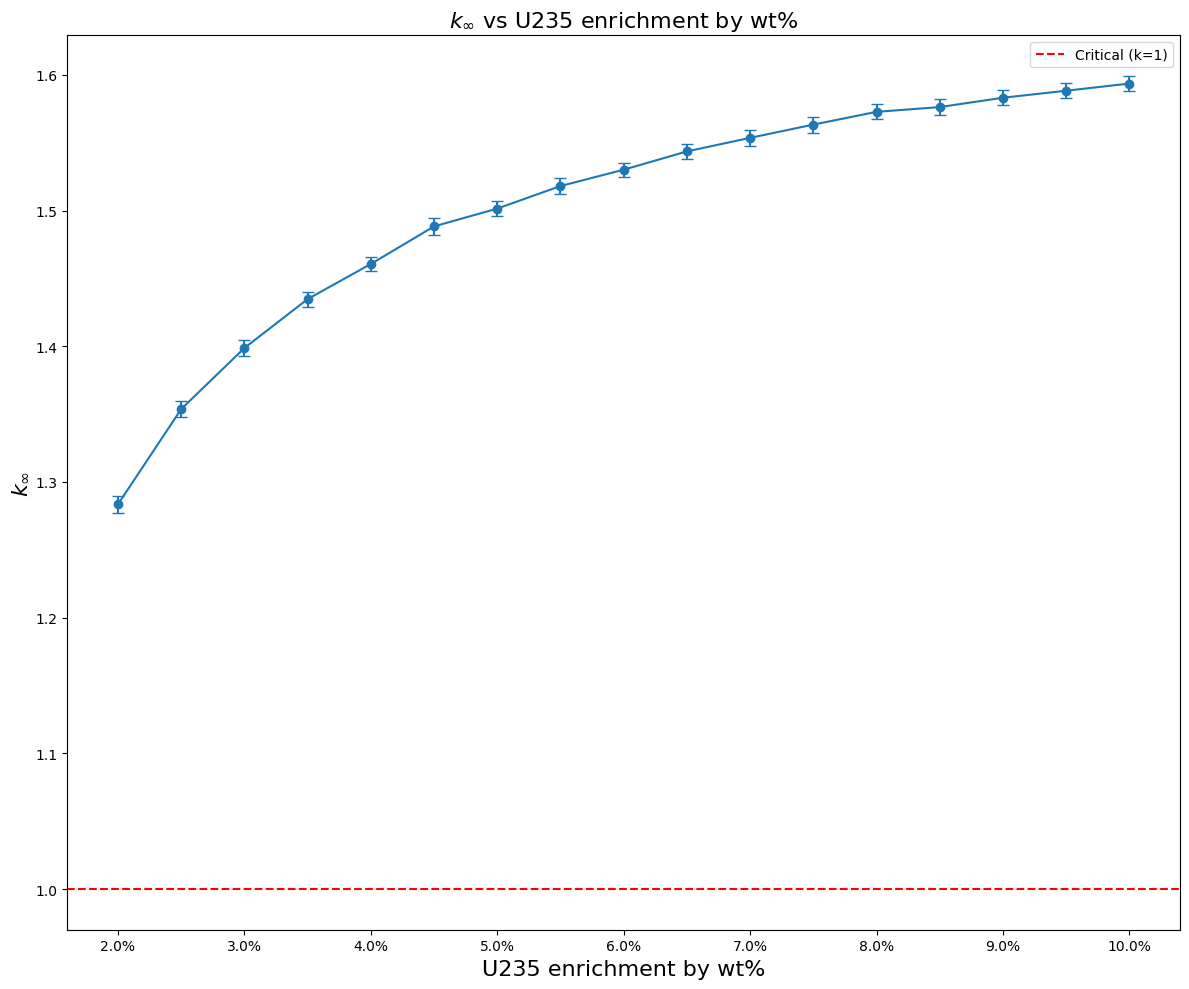

In [17]:
# Plot the results
yerr = [df_keff['keff'] - df_keff['keff_lower'], df_keff['keff_upper'] - df_keff['keff']]
fig, ax = plt.subplots(figsize=(12, 10))
ax.errorbar(df_keff['U235_enrichment_wt%'], df_keff['keff'], yerr=yerr, fmt='o-', capsize=4)
ax.set_xlabel('U235 enrichment by wt%', fontsize=16)
ax.set_ylabel(r'$k_{\infty}$', fontsize=16)
ax.set_title(r'$k_{\infty}$ vs U235 enrichment by wt%', fontsize=16)
ax.axhline(y=1.0, color='r', linestyle='--', label='Critical (k=1)')
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(directory_, 'keff_fig.png'), dpi=300)